#Natural Language Processing

### 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


##2. Loading the Dataset

In [ ]:
df = pd.read_csv("amazonreviews.tsv", sep="\t")

print(df.head())
print(df.shape)
print(df.columns)


  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...
(10000, 2)
Index(['label', 'review'], dtype='object')


#3.Data Cleaning

In [ ]:
df.columns = df.columns.str.strip()
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print("After cleaning:", df.shape)

After cleaning: (10000, 2)


### 4. Text Preprocessing

In [ ]:
nltk.download('stopwords')

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub('[^a-z]', ' ', text)
    words = text.split()
    words = [ps.stem(w) for w in words if w not in stop_words]
    return " ".join(words)

df['clean_review'] = df['review'].apply(preprocess)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 5. Exploratory Analysis

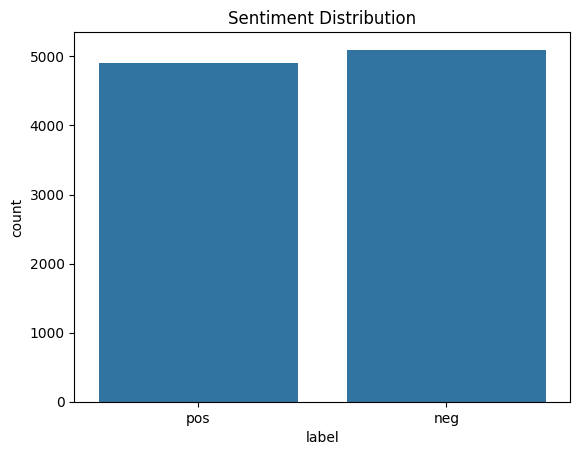

In [ ]:
sns.countplot(x='label', data=df)
plt.title("Sentiment Distribution")
plt.show()

## 6. Feature Extraction

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review']).toarray()

# Convert labels
y = df['label'].map({'pos': 1, 'neg': 0})

## 7. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 8. Model

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#9. Evaluation

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.853
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1037
           1       0.85      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



#10. Confusion Matrix

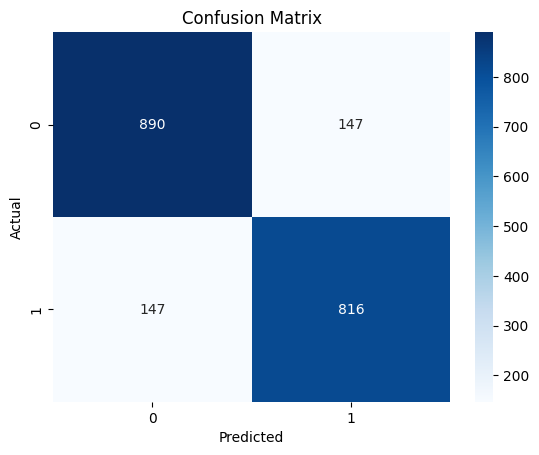

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#11. Cross Validation

In [ ]:
scores = cross_val_score(model, X, y, cv=5, scoring='f1')

print("Cross Validation F1 Scores:", scores)
print("Average F1 Score:", scores.mean())


Cross Validation F1 Scores: [0.8470948  0.82142857 0.80897704 0.82677568 0.8499744 ]
Average F1 Score: 0.8308500967121267


#12. Threshold Tunning

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

for t in [0.3, 0.5, 0.7]:
    y_new = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_new))



Threshold: 0.3
              precision    recall  f1-score   support

           0       0.96      0.59      0.73      1037
           1       0.69      0.97      0.80       963

    accuracy                           0.77      2000
   macro avg       0.82      0.78      0.77      2000
weighted avg       0.83      0.77      0.76      2000


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1037
           1       0.85      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


Threshold: 0.7
              precision    recall  f1-score   support

           0       0.71      0.97      0.82      1037
           1       0.95      0.56      0.71       963

    accuracy                           0.78      2000
   macro avg       0.83      0.77      0.76      2000
weighted avg       0.82   

#13. World Cloud(Visualization)

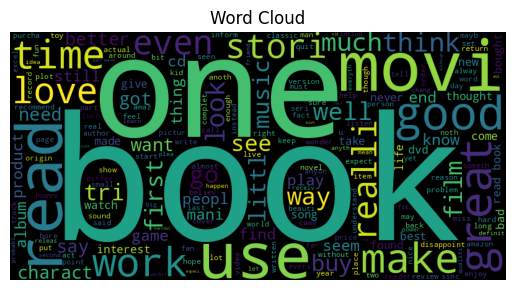

In [ ]:
from wordcloud import WordCloud

text = " ".join(df['clean_review'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.title("Word Cloud")
plt.show()

#Conclusion

The NLP model was built using TF-IDF feature extraction and Logistic Regression.
After preprocessing and cleaning the text data, the model achieved good classification performance.
Cross-validation confirmed model stability, and threshold tuning helped balance precision and recall.
Visualization techniques like word clouds provided insights into frequent terms.

However, TF-IDF has limitations in capturing context. Advanced techniques such as Word2Vec and BERT can further improve performance by understanding semantic meaning.

Overall, the model demonstrates how machine learning can be applied to sentiment analysis effectively.
